In [ ]:
from pathlib import Path
from imd_features.config import FeatureSetConfig, GroupConfig, ReductionMethod
from imd_features.process import create_feature_set
from imd_features.inspect import (
    group_summary,
    correlation_within_groups,
    correlation_between_groups,
    correlation_full,
    distribution_plot,
)
import polars as pl
from project_paths import paths


In [ ]:

output_dir = paths.output

config_path = output_dir / "mixed_reduction_b78f17cd_config.json" 
config = FeatureSetConfig.model_validate_json(config_path.read_text())

df = pl.read_parquet(output_dir / f"{config.output_name}.parquet")
metadata = {}  # not available when loading from disk


In [3]:
df.describe()

statistic,lsoa_code,violent-crime,burglary,anti-social-behaviour,shoplifting,criminal-damage-arson,drugs,total_crimes,resolution_rate,connectivity_pca_1,connectivity_pca_2
str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""","""268""",268.0,268.0,268.0,268.0,268.0,268.0,268.0,268.0,268.0,268.0
"""null_count""","""0""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",null,1.3256e-17,-3.9769e-17,-1.3256e-17,1.6570e-17,-3.9769e-17,-2.6513e-17,2.6513e-17,9.0143e-16,-1.3256e-16,0.0
"""std""",null,1.001871,1.001871,1.001871,1.001871,1.001871,1.001871,1.001871,1.001871,2.18129,0.393385
"""min""","""E01014485""",-1.022558,-1.108535,-0.681682,-0.398099,-1.053593,-0.736341,-0.862931,-5.24598,-5.614567,-1.253948
"""25%""",null,-0.590811,-0.625466,-0.454975,-0.398099,-0.630442,-0.623897,-0.493497,-0.459656,-1.511349,-0.26502
"""50%""",null,-0.284044,-0.263164,-0.280586,-0.379138,-0.26774,-0.286565,-0.276582,0.15649,0.166904,-0.002492
"""75%""",null,0.318129,0.340672,0.068194,-0.113692,0.276312,0.275656,0.143691,0.625903,1.70572,0.269126
"""max""","""E01033910""",8.032763,8.673608,9.938662,7.830735,9.404297,10.395625,9.779474,1.956588,3.826856,1.028429


In [4]:
group_summary(config, metadata)

group,input_features,output_features,scaled,reduction,explained_var
str,i64,i64,bool,str,f64
"""crime""",8,8,true,"""none""",null
"""connectivity""",5,2,true,"""pca""",0.9789


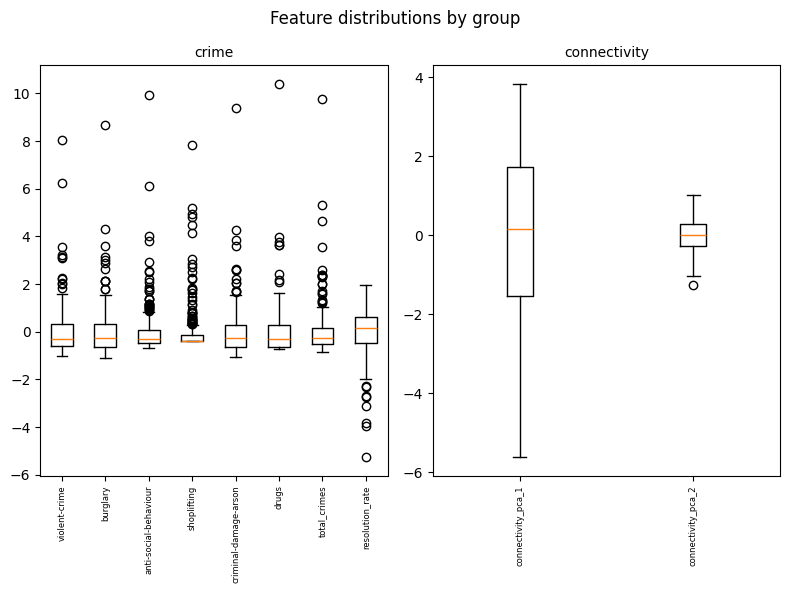

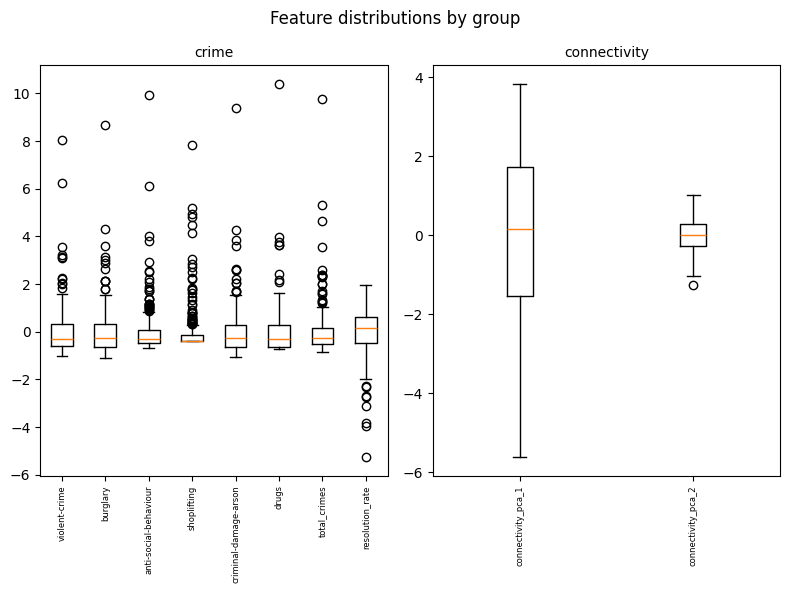

In [5]:
distribution_plot(df, config)

C:\Users\Daniel\AppData\Local\Temp\ipykernel_19168\1389867195.py:3: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


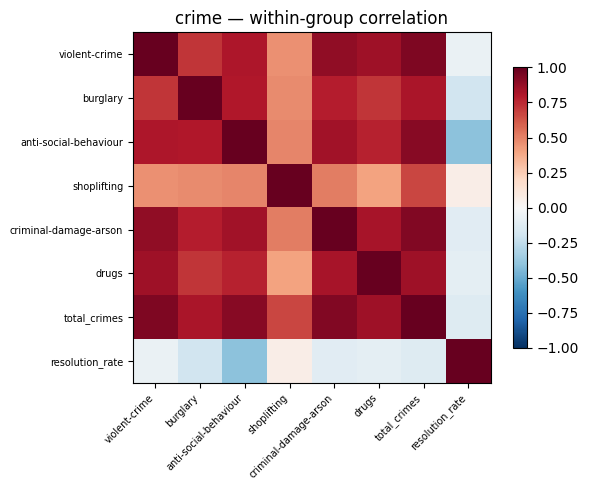

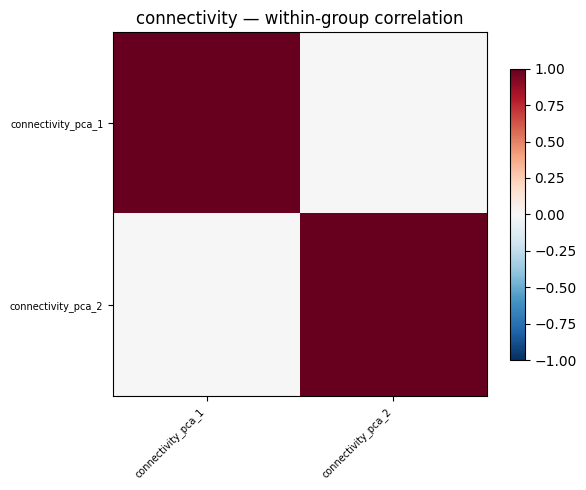

In [6]:
within_corrs = correlation_within_groups(df, config)
for name, fig in within_corrs.items():
    fig.show()

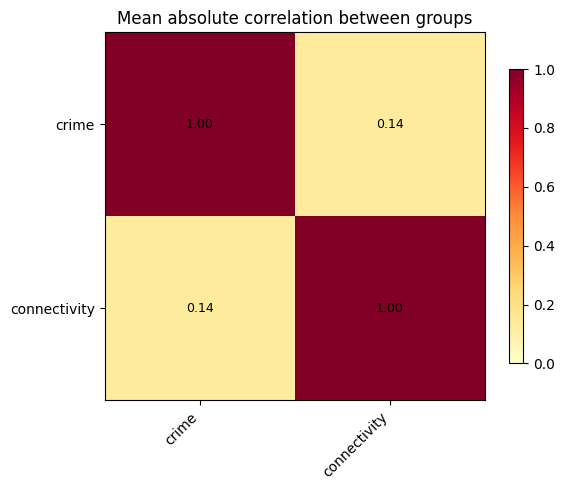

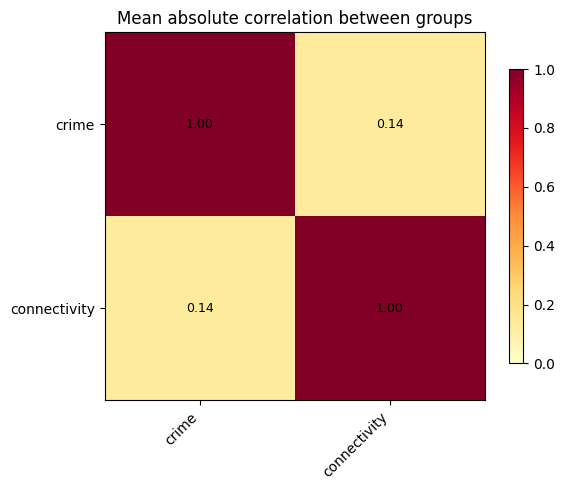

In [7]:
correlation_between_groups(df, config)

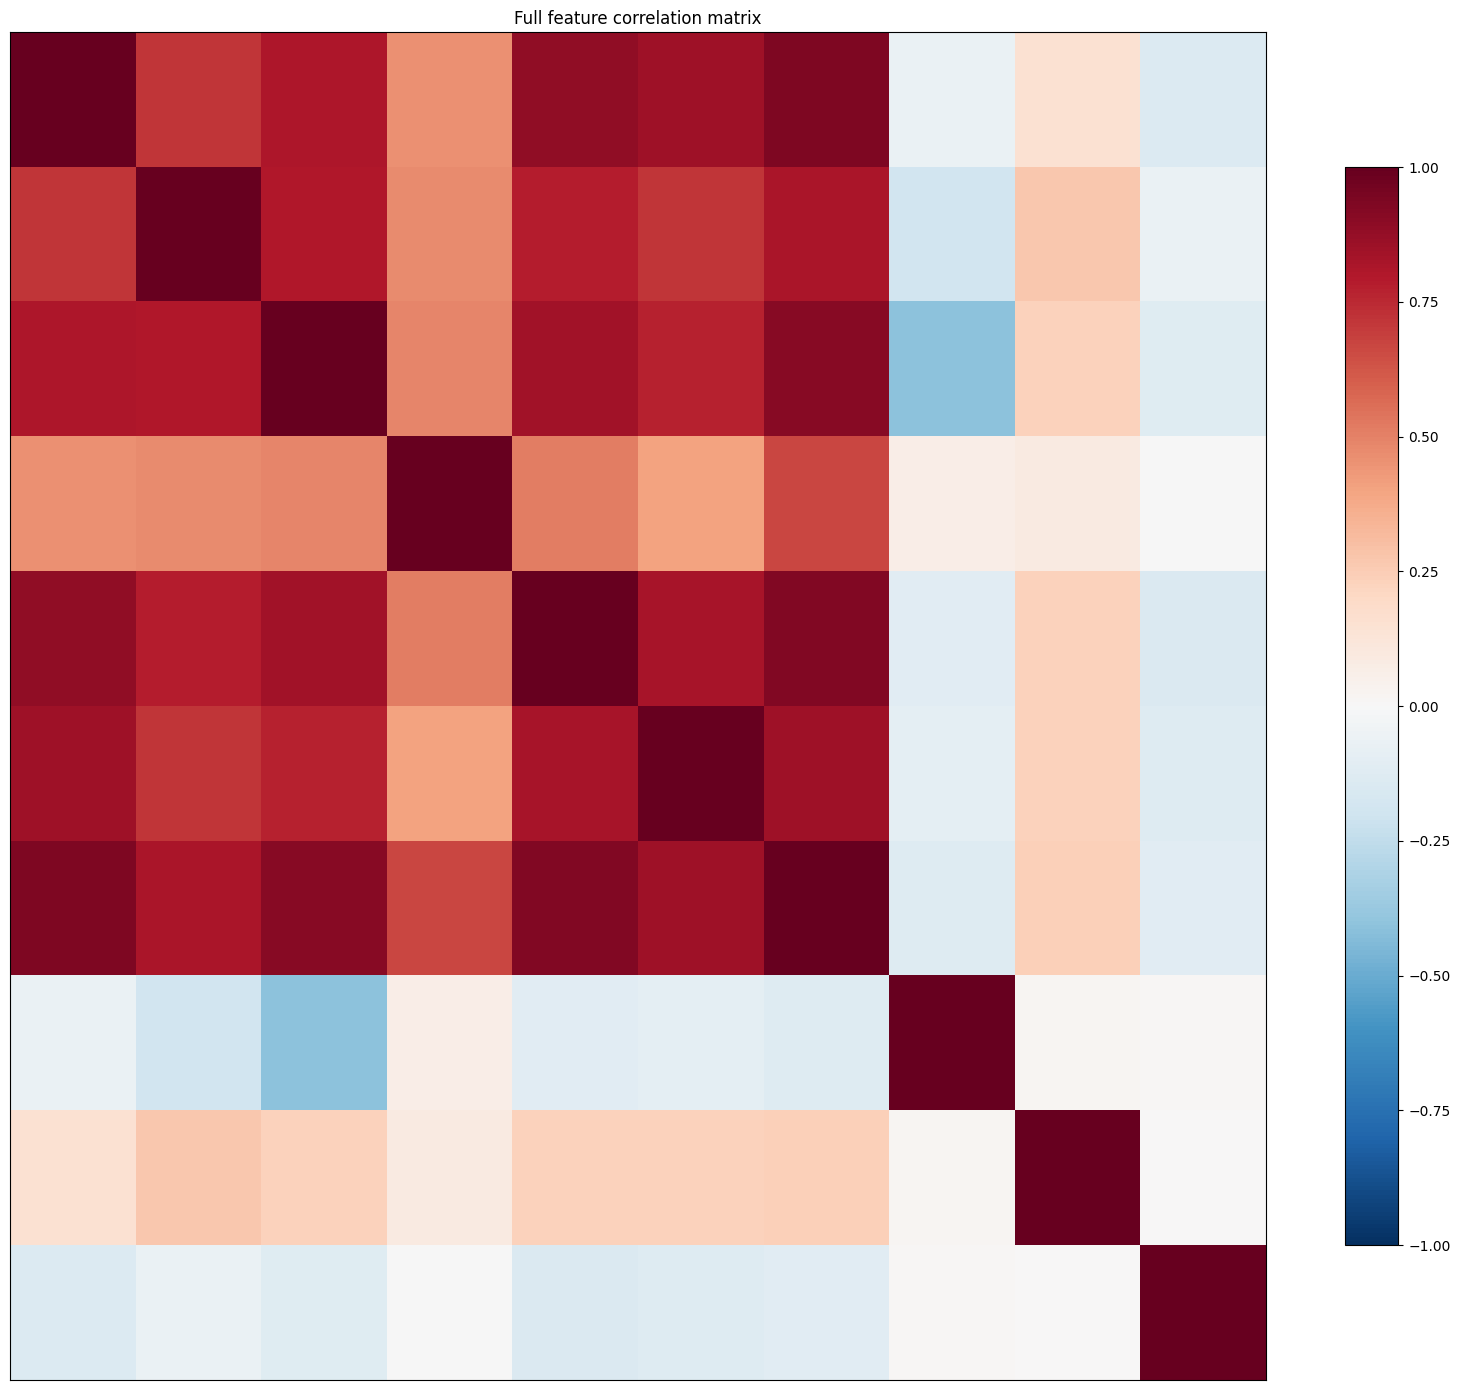

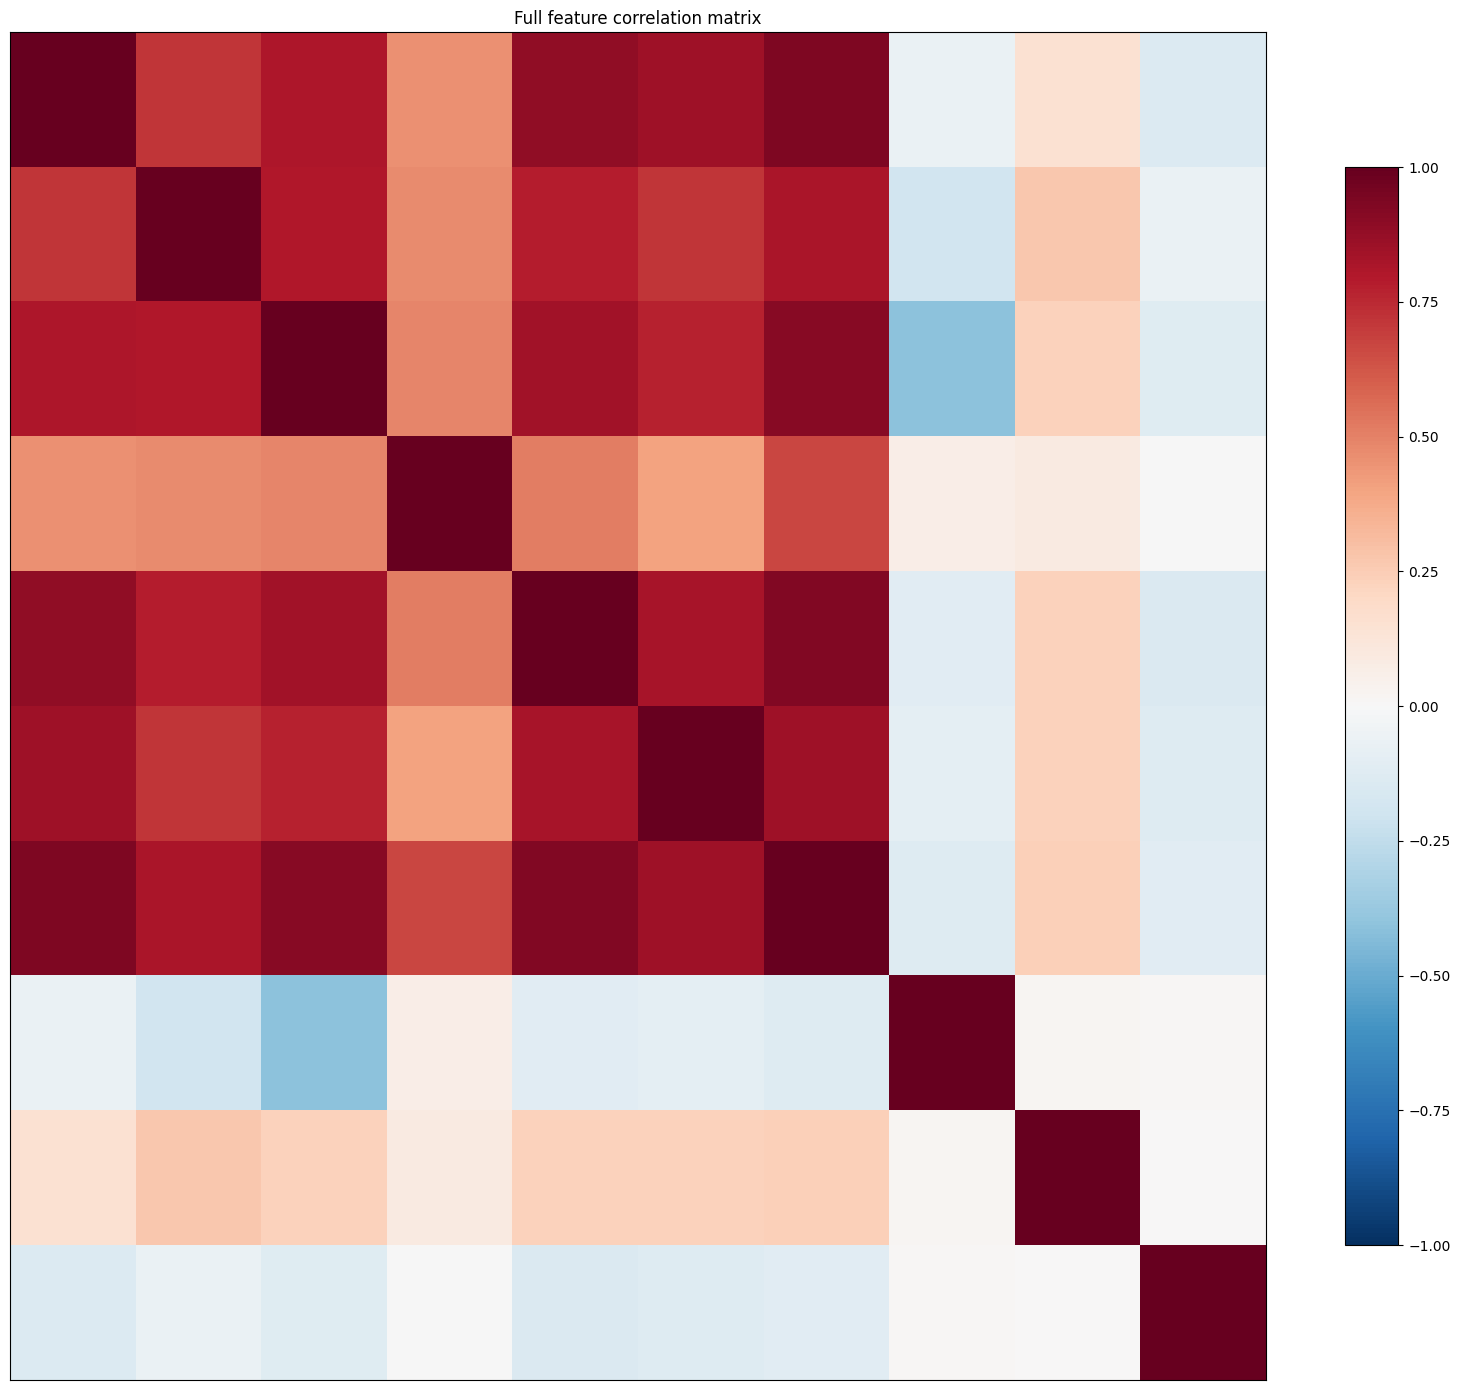

In [8]:
correlation_full(df)